# ⚗ MIDAS LAB — Pipeline de Inteligência Preditiva para Ações da B3

> **Versão:** 3.0 | **Autores:** Kaue Mandarino · Yago Cavalcante · Hélio Oliveira

---

## 🎯 Objetivo

Identificar, entre todas as ações da B3, quais têm comportamento **suficientemente previsível** para que um modelo simples de regressão linear consiga antecipar sua direção de preço — e se esse crescimento supera a **Selic**, tornando-as candidatas a compra.

---

## 🗺️ Estrutura do Notebook

| Célula | O que faz |
|---|---|
| 1 | Importações e configuração do ambiente |
| 2 | Consulta de teste — ITUB4 (entendendo o yfinance) |
| 3 | Busca de parâmetros — 7 janelas × todas as empresas B3 |
| 4 | Pipeline final — previsões individuais + Excel + gráficos |
| 5 | Backtest — prova real com R$ 100k simulados |
| 6 | Análise final e conclusões |

---

### ⚠️ Correções v3.0
- **Bug de direção corrigido:** delta e direção agora usam o **último dia** da projeção (não a média), evitando classificar como ALTA ações cuja tendência aponta para queda
- **Período de coleta corrigido:** gráficos usam exatamente 7 meses de treino + 3 meses de teste
- **Rótulos verticais** adicionados nos pontos de projeção futura (M+1, M+2, M+3)

> ⚠️ *Sugestão algorítmica. Não constitui recomendação de investimento.*

In [1]:
# ============================================================
# CÉLULA 1 — IMPORTAÇÕES E CONFIGURAÇÃO
# ============================================================
# Execute esta célula uma única vez antes de qualquer outra.

# Instalar dependências (rode apenas na primeira execução)
# !pip install yfinance pandas numpy matplotlib plotly scikit-learn python-dotenv python-dateutil openpyxl -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# PARÂMETROS GLOBAIS — resultado do experimento de 7 janelas
# Janela de 7 meses foi a mais assertiva sobre a B3
# ------------------------------------------------------------
DIAS_TREINO  = 147    # 7 meses — janela vencedora
N_TESTE      = 63     # 3 meses de teste (período já ocorrido)
N_FUTURO     = 63     # 3 meses de projeção futura
SELIC_ANUAL  = 13.75  # % ao ano — atualize conforme taxa vigente
SELIC_3M     = (SELIC_ANUAL / 12) * 3
THRESHOLD    = SELIC_3M + 0.5  # retorno mínimo para sugerir compra

print('✅ Ambiente configurado com sucesso')
print(f'   Janela de treino  : {DIAS_TREINO} dias úteis (~7 meses)')
print(f'   Janela de teste   : {N_TESTE} dias úteis (~3 meses)')
print(f'   Selic 3m ref.     : {SELIC_3M:.2f}%')
print(f'   Threshold compra  : {THRESHOLD:.2f}% (Selic + 0.5%)')

c:\Users\Kaue Mandarino\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Kaue Mandarino\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


✅ Ambiente configurado com sucesso
   Janela de treino  : 147 dias úteis (~7 meses)
   Janela de teste   : 63 dias úteis (~3 meses)
   Selic 3m ref.     : 3.44%
   Threshold compra  : 3.94% (Selic + 0.5%)


---
## 🔬 Célula 2 — Consulta de Teste: ITUB4

Validação da conexão com o Yahoo Finance e exploração da estrutura dos dados antes de rodar em escala.

Registros coletados  : 750
Período              : 2023-05-29 → 2026-05-29

Colunas disponíveis  : ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']

Últimos 5 dias:


,Open,High,Low,Close,Volume
Date,,,,,
2026-05-25 00:00:00-03:00,39.860001,40.490002,39.860001,40.320000,11436200
2026-05-26 00:00:00-03:00,40.220001,40.360001,39.650002,40.060001,23046600
2026-05-27 00:00:00-03:00,40.599998,40.820000,40.290001,40.320000,21601400
2026-05-28 00:00:00-03:00,40.320000,40.450001,39.720001,40.000000,20196600
2026-05-29 00:00:00-03:00,39.869999,40.160000,39.540001,40.040001,80334400


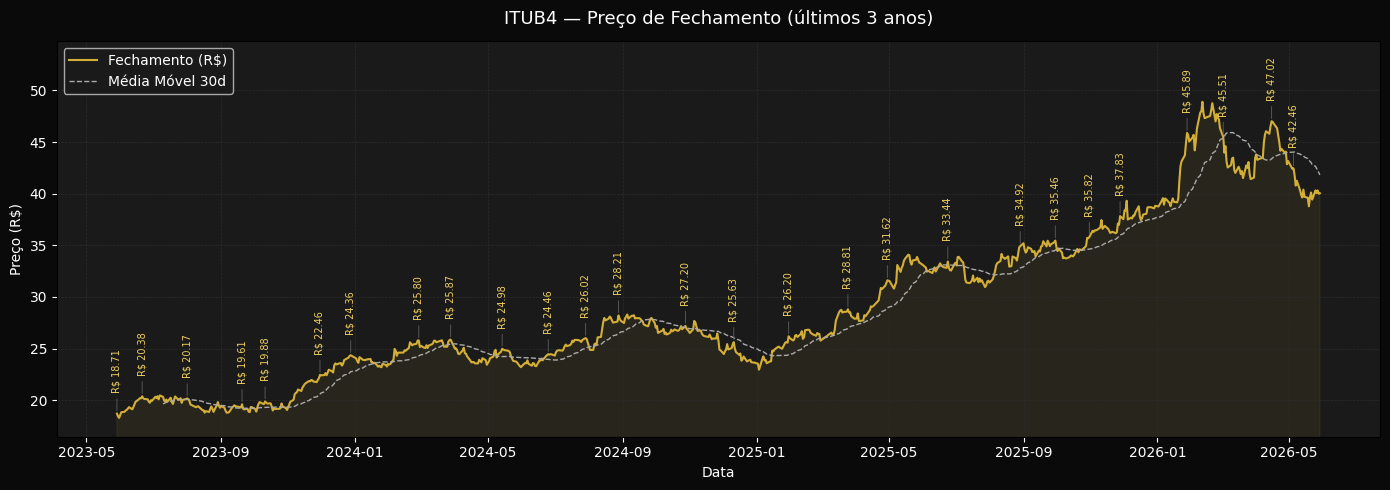

In [2]:
# ============================================================
# CÉLULA 2 — CONSULTA DE TESTE: ITUB4
# ============================================================

ticker = yf.Ticker('ITUB4.SA')

# baixa 3 anos só para visualização histórica
df_viz = ticker.history(period='3y', interval='1d')

print(f'Registros coletados  : {len(df_viz)}')
print(f'Período              : {df_viz.index[0].date()} → {df_viz.index[-1].date()}')
print(f'\nColunas disponíveis  : {df_viz.columns.tolist()}')
print(f'\nÚltimos 5 dias:')
display(df_viz[['Open','High','Low','Close','Volume']].tail())

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_viz.index, df_viz['Close'], color='#D4AF37', linewidth=1.5, label='Fechamento (R$)')
ax.fill_between(df_viz.index, df_viz['Close'], alpha=0.08, color='#D4AF37')
mm30 = df_viz['Close'].rolling(30).mean()
ax.plot(df_viz.index, mm30, color='#AAAAAA', linewidth=1, linestyle='--', label='Média Móvel 30d')

# rótulos mensais de máximos na vertical
df_viz['month'] = df_viz.index.to_period('M')
pontos, prev_x = [], None
for periodo, grupo in df_viz.groupby('month'):
    idx_max = grupo['Close'].idxmax()
    pontos.append((idx_max, grupo['Close'].max()))

y_max = df_viz['Close'].max()
margem = y_max * 1.12
ax.set_ylim(df_viz['Close'].min() * 0.90, margem)

for (x, y) in pontos:
    if prev_x and (x - prev_x).days < 20:
        continue
    y_lbl = min(y + y_max * 0.04, margem * 0.97)
    ax.annotate(f'R$ {y:.2f}', xy=(x, y), xytext=(x, y_lbl),
                textcoords='data', ha='center', fontsize=7,
                color='#F0D060', rotation=90, va='bottom',
                arrowprops=dict(arrowstyle='-', color='#555555', lw=0.7))
    prev_x = x

ax.set_title('ITUB4 — Preço de Fechamento (últimos 3 anos)', color='white', fontsize=13, pad=12)
ax.set_xlabel('Data', color='white'); ax.set_ylabel('Preço (R$)', color='white')
ax.tick_params(colors='white'); ax.legend(facecolor='#1A1A1A', labelcolor='white')
ax.grid(color='#2C2C2C', linestyle='--', linewidth=0.5)
ax.set_facecolor('#1A1A1A'); fig.patch.set_facecolor('#0A0A0A')
plt.tight_layout(); plt.show()

---
## 🔬 Célula 3 — Busca de Parâmetros Ótimos

**Pergunta:** qual janela de treino produz previsões mais assertivas?

Testamos **7 janelas** (de 1 mês a 3 anos) sobre **~400 empresas da B3**.

**Resultado:** janela de **7 meses** venceu com Score 73.4.

Total de tickers: 246
Processando 246 tickers | 7 janelas cada...



HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AZUL4.SA"}}}
$AZUL4.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: BRFS3.SA"}}}
$BRFS3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$CCRO3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$CPLE6.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$CRFB3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$ELET3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$ELET6.SA: possibly deli

  ✔ 50/246 | ok: 42 | falhas: 8


$JBSS3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$MRFG3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$NTCO3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$ARZZ3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")


  ✔ 100/246 | ok: 88 | falhas: 12


...

  ✔ 150/246 | ok: 134 | falhas: 16


$RLOG3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$RRRP3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$SMAG3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$SOMA3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$SQIA3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$STBP3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$SULA11.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$TRPL4.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$AGTE3.SA: possibly delisted; no price data fou

  ✔ 200/246 | ok: 172 | falhas: 28


$CLSA3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$ENAT3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$FRTA3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$HGTX3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$HMTL3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$JPSA3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$MIXT3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$NAIL3.SA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$NCAB3.SA: possibly delisted; no price data foun


✅ Concluído — 202 empresas válidas | 44 falhas

═════════════════════════════════════════════════════════════════
  RESULTADO — 202 EMPRESAS B3 | 7 JANELAS
═════════════════════════════════════════════════════════════════
         Empresas  MAPE médio (%)  MAPE mediana (%)  Acerto Dir. (%)      R² médio  ⭐ Score
7 meses     202.0           34.32             13.73             46.8 -3.060660e+01     73.4
8 meses     202.0           38.32             14.34             46.4 -4.020980e+01     73.2
9 meses     202.0           38.92             13.72             46.5 -5.153410e+01     73.2
1 ano       202.0           35.27             11.00             46.1 -8.073210e+01     73.0
2 anos      202.0          559.62             13.06             45.5 -2.169147e+05     70.5
3 anos      202.0        11871.16             16.41             46.2 -1.186271e+08     23.1
═════════════════════════════════════════════════════════════════
  🏆  Janela mais assertiva : 7 meses
      Score               : 73

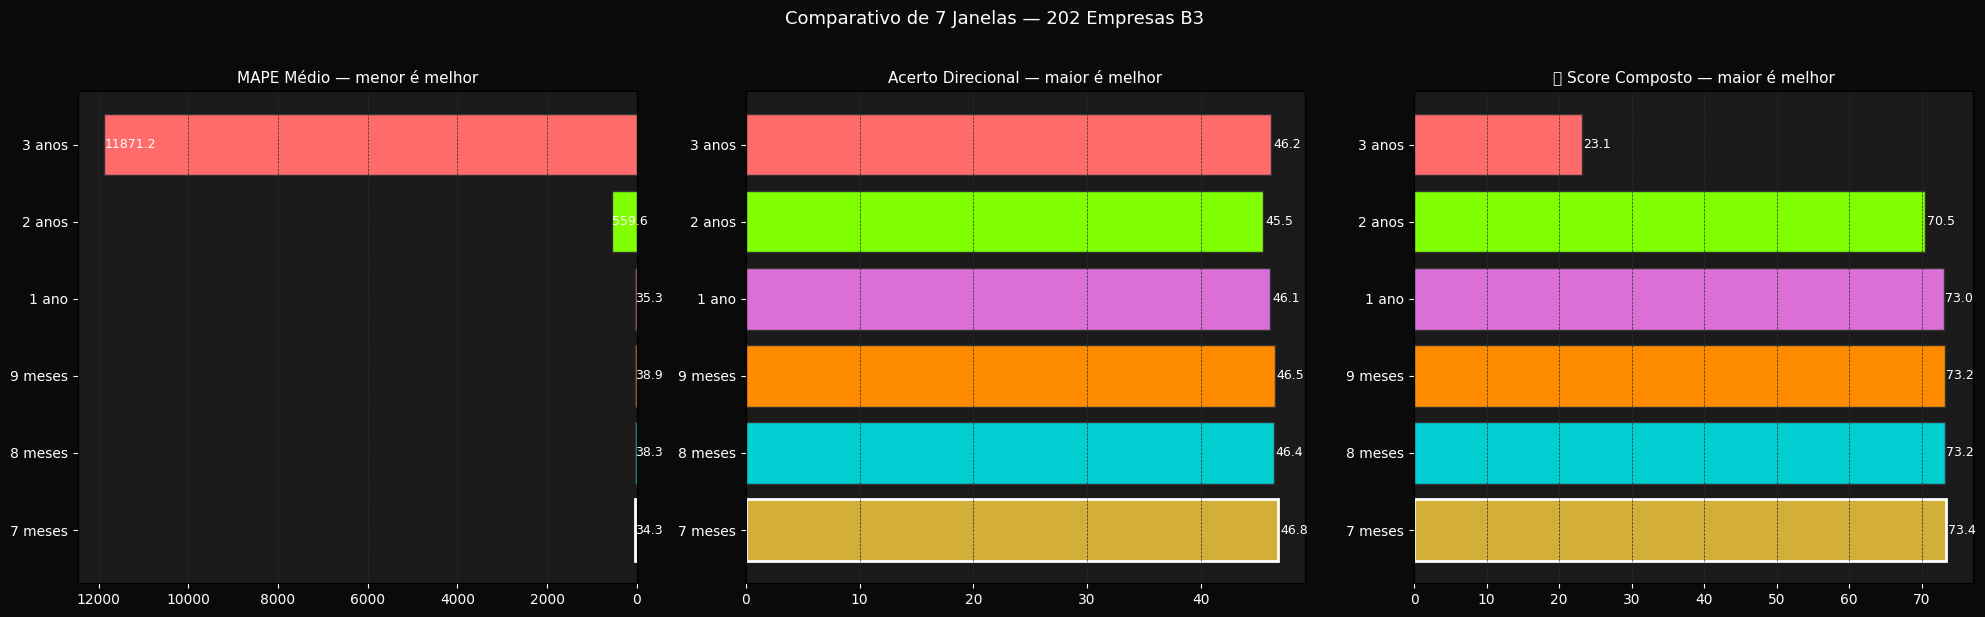

In [3]:
# ============================================================
# CÉLULA 3 — BUSCA DE PARÂMETROS: 7 JANELAS × B3
# ============================================================

tickers_b3 = [
    'ABEV3.SA','ASAI3.SA','AZUL4.SA','B3SA3.SA','BBAS3.SA',
    'BBDC3.SA','BBDC4.SA','BBSE3.SA','BEEF3.SA','BHIA3.SA',
    'BPAC11.SA','BRAP4.SA','BRKM5.SA','BRFS3.SA','CBAV3.SA',
    'CCRO3.SA','CMIN3.SA','CMIG4.SA','COGN3.SA','CPFE3.SA',
    'CPLE3.SA','CPLE6.SA','CRFB3.SA','CSAN3.SA','CSNA3.SA',
    'CVCB3.SA','CXSE3.SA','CYRE3.SA','DXCO3.SA','ECOR3.SA',
    'EGIE3.SA','ELET3.SA','ELET6.SA','EMBR3.SA','EMBJ3.SA',
    'ENEV3.SA','ENGI11.SA','EQTL3.SA','FLRY3.SA','GGBR3.SA',
    'GGBR4.SA','GOAU3.SA','GOAU4.SA','GMAT3.SA','HAPV3.SA',
    'HYPE3.SA','IGTI11.SA','IRBR3.SA','ITSA4.SA','ITUB3.SA',
    'ITUB4.SA','JBSS3.SA','JHSF3.SA','KLBN11.SA','KLBN4.SA',
    'LREN3.SA','LWSA3.SA','MGLU3.SA','MOVI3.SA','MRFG3.SA',
    'MRVE3.SA','MULT3.SA','NATU3.SA','NTCO3.SA','PETR3.SA',
    'PETR4.SA','PRIO3.SA','PSSA3.SA','QUAL3.SA','RADL3.SA',
    'RAIL3.SA','RAIZ4.SA','RDOR3.SA','RENT3.SA','SANB11.SA',
    'SBSP3.SA','SLCE3.SA','SMFT3.SA','SUZB3.SA','TAEE11.SA',
    'TIMS3.SA','TOTS3.SA','UGPA3.SA','USIM3.SA','USIM5.SA',
    'VALE3.SA','VAMO3.SA','VBBR3.SA','VIVT3.SA','WEGE3.SA',
    'YDUQ3.SA','AGRO3.SA','ALOS3.SA','ALUP11.SA','AMAR3.SA',
    'ANIM3.SA','ARML3.SA','ARZZ3.SA','AURE3.SA','AUAU3.SA',
    'AXIA3.SA','AZZA3.SA','BPAN4.SA','BRAV3.SA','BRML3.SA',
    'BRPR3.SA','BRSR6.SA','CAML3.SA','CASH3.SA','CEAB3.SA',
    'CESP6.SA','CGAS5.SA','CGRA4.SA','CMIG3.SA','CSMG3.SA',
    'CURY3.SA','DESK3.SA','DIRR3.SA','DMVF3.SA','EVEN3.SA',
    'EZTC3.SA','FESA4.SA','FIQE3.SA','GGPS3.SA','GRND3.SA',
    'HBSA3.SA','INTB3.SA','ISAE4.SA','JSLG3.SA','KEPL3.SA',
    'LAVV3.SA','LEVE3.SA','LIGT3.SA','LJQQ3.SA','LOG3.SA',
    'LOGN3.SA','MBRF3.SA','MDIA3.SA','MELK3.SA','MILS3.SA',
    'MOTV3.SA','MYPK3.SA','NEOE3.SA','ONCO3.SA','ODPV3.SA',
    'OIBR3.SA','PCAR3.SA','PGMN3.SA','PINE4.SA','PLPL3.SA',
    'PNVL3.SA','POMO4.SA','POSI3.SA','RAPT4.SA','RCSL4.SA',
    'RECV3.SA','RLOG3.SA','ROMI3.SA','RRRP3.SA','SAPR11.SA',
    'SAUD3.SA','SBFG3.SA','SEER3.SA','SEQL3.SA','SIMH3.SA',
    'SMAG3.SA','SMTO3.SA','SOMA3.SA','SQIA3.SA','STBP3.SA',
    'SULA11.SA','TASA4.SA','TEND3.SA','TFCO4.SA','TRPL4.SA',
    'TTEN3.SA','TUPY3.SA','UCAS3.SA','UNIP6.SA','VIVA3.SA',
    'VLID3.SA','VULC3.SA','WEST3.SA','WIZC3.SA',
    'AALR3.SA','ABCB4.SA','AERI3.SA','AFLT3.SA','AGXY3.SA',
    'AGTE3.SA','AHEB3.SA','ALPA4.SA','ALSO3.SA','AMOB3.SA',
    'APER3.SA','ATMP3.SA','BAUH4.SA','BEES3.SA','BLAU3.SA',
    'BMGB4.SA','CAMB3.SA','CEEB3.SA','CEED4.SA','CLSA3.SA',
    'COCE5.SA','DASA3.SA','ENAT3.SA','ESPA3.SA','FHER3.SA',
    'FRTA3.SA','GFSA3.SA','HBOR3.SA','HETA4.SA','HGTX3.SA',
    'HMTL3.SA','JALL3.SA','JPSA3.SA','LAND3.SA','LPSB3.SA',
    'MDNE3.SA','MIXT3.SA','MNPR3.SA','NAIL3.SA','NCAB3.SA',
    'NEXP3.SA','NGRD3.SA','OFSA3.SA','ORVR3.SA','PARD3.SA',
    'PDGR3.SA','PETZ3.SA','PMAM3.SA','PTBL3.SA','RPMG3.SA',
    'RSUL4.SA','SAPR3.SA','SCAR3.SA','SOJA3.SA','SYNE3.SA',
    'TEKA4.SA','TGMA3.SA','TPVT3.SA','UPAR3.SA','VERS3.SA',
    'VIIA3.SA','XBXA3.SA',
]
tickers_b3 = list(dict.fromkeys(tickers_b3))
print(f'Total de tickers: {len(tickers_b3)}')

periodos = {
    '1 mês'  : {'days': 21},
    '7 meses': {'days': 147},
    '8 meses': {'days': 168},
    '9 meses': {'days': 189},
    '1 ano'  : {'days': 252},
    '2 anos' : {'days': 504},
    '3 anos' : {'days': 756},
}

acumulado = {p: {'mape': [], 'acerto_dir': [], 'r2': []} for p in periodos}
falhas, sucesso = [], 0
print(f'Processando {len(tickers_b3)} tickers | 7 janelas cada...\n')

for i, tk in enumerate(tickers_b3, 1):
    try:
        raw = yf.Ticker(tk).history(period='3y', interval='1d')[['Close']].copy()
        raw.index = pd.to_datetime(raw.index.date)
        raw = raw.dropna().reset_index(drop=False)
        raw.columns = ['Data', 'Close']
        raw['t'] = np.arange(len(raw))
        if len(raw) < N_TESTE + 30:
            falhas.append((tk, 'dados insuficientes')); continue
        ticker_ok = False
        for nome, cfg in periodos.items():
            n_usar = min(cfg['days'], len(raw))
            df = raw.iloc[-n_usar:].copy().reset_index(drop=True)
            df['t'] = np.arange(len(df))
            if len(df) <= N_TESTE + 10: continue
            df_train = df.iloc[:-N_TESTE]
            df_test  = df.iloc[-N_TESTE:]
            model = LinearRegression()
            model.fit(df_train[['t']], df_train['Close'])
            y_pred = model.predict(df_test[['t']])
            y_real = df_test['Close'].values
            mape   = np.mean(np.abs((y_real - y_pred) / (y_real + 1e-9))) * 100
            r2     = r2_score(y_real, y_pred)
            acerto = np.mean(np.sign(np.diff(y_real)) == np.sign(np.diff(y_pred))) * 100
            acumulado[nome]['mape'].append(mape)
            acumulado[nome]['acerto_dir'].append(acerto)
            acumulado[nome]['r2'].append(r2)
            ticker_ok = True
        if ticker_ok: sucesso += 1
    except Exception as e:
        falhas.append((tk, str(e)))
    if i % 50 == 0:
        print(f'  ✔ {i}/{len(tickers_b3)} | ok: {sucesso} | falhas: {len(falhas)}')

print(f'\n✅ Concluído — {sucesso} empresas válidas | {len(falhas)} falhas\n')

resumo = {}
for nome in periodos:
    v = acumulado[nome]
    if not v['mape']: continue
    resumo[nome] = {
        'Empresas'        : len(v['mape']),
        'MAPE médio (%)'  : round(np.mean(v['mape']), 2),
        'MAPE mediana (%)': round(np.median(v['mape']), 2),
        'Acerto Dir. (%)' : round(np.mean(v['acerto_dir']), 1),
        'R² médio'        : round(np.mean(v['r2']), 4),
    }

df_resumo = pd.DataFrame(resumo).T
mape_v = df_resumo['MAPE médio (%)'].astype(float)
mape_n = 100 - (mape_v - mape_v.min()) / (mape_v.max() - mape_v.min() + 1e-9) * 100
acd_v  = df_resumo['Acerto Dir. (%)'].astype(float)
df_resumo['⭐ Score'] = (0.5 * mape_n + 0.5 * acd_v).round(1)
df_resumo = df_resumo.sort_values('⭐ Score', ascending=False)
MELHOR = df_resumo.index[0]

print('═' * 65)
print(f'  RESULTADO — {sucesso} EMPRESAS B3 | 7 JANELAS')
print('═' * 65)
print(df_resumo.to_string())
print('═' * 65)
print(f'  🏆  Janela mais assertiva : {MELHOR}')
print(f'      Score               : {df_resumo.loc[MELHOR, "⭐ Score"]}')
print(f'      MAPE médio          : {df_resumo.loc[MELHOR, "MAPE médio (%)"]:.2f}%')
print(f'      Acerto Direcional   : {df_resumo.loc[MELHOR, "Acerto Dir. (%)"]:.1f}%')
print('═' * 65)

janelas   = list(df_resumo.index)
cores     = ['#D4AF37','#00CED1','#FF8C00','#DA70D6','#7FFF00','#FF6B6B','#87CEEB']
cores_map = {j: c for j, c in zip(janelas, cores)}
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
metricas = [
    ('MAPE médio (%)',  'MAPE Médio — menor é melhor',        True),
    ('Acerto Dir. (%)', 'Acerto Direcional — maior é melhor', False),
    ('⭐ Score',        '⭐ Score Composto — maior é melhor',  False),
]
for ax, (col, titulo, inv) in zip(axes, metricas):
    vals = df_resumo.loc[janelas, col].astype(float)
    bars = ax.barh(janelas, vals, color=[cores_map[j] for j in janelas], edgecolor='#333333')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', color='white', fontsize=9)
    for patch, label in zip(bars, janelas):
        if label == MELHOR:
            patch.set_edgecolor('#FFFFFF'); patch.set_linewidth(2)
    if inv: ax.invert_xaxis()
    ax.set_title(titulo, color='white', fontsize=11)
    ax.tick_params(colors='white')
    ax.grid(color='#2C2C2C', linestyle='--', linewidth=0.5, axis='x')
    ax.set_facecolor('#1A1A1A')
fig.patch.set_facecolor('#0A0A0A')
fig.suptitle(f'Comparativo de 7 Janelas — {sucesso} Empresas B3', color='white', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 📊 Célula 4 — Pipeline Completo: Previsões Individuais

### ⚠️ Correções aplicadas nesta versão:

**1. Período de coleta correto:**
Agora coletamos exatamente `DIAS_TREINO + N_TESTE` dias úteis — 7 meses de treino + 3 meses de teste. O gráfico mostra exatamente esse período, sem dados extras que distorciam a visualização.

**2. Delta e Direção corrigidos:**
Antes usávamos a *média* dos 63 dias futuros. Uma ação em queda pode ter média > preço atual se a linha ainda não cruzou para baixo no início. Agora usamos o **último dia da projeção** — se a linha termina abaixo do preço atual, é QUEDA.

**3. Rótulos verticais na projeção:**
Os pontos M+1, M+2 e M+3 são marcados no gráfico com o preço previsto em rótulo vertical.

In [4]:
# ============================================================
# CÉLULA 4 — PIPELINE COMPLETO: PREVISÕES INDIVIDUAIS
# ============================================================

PASTA = 'resultado'
os.makedirs(PASTA, exist_ok=True)
resultados = []

# ------------------------------------------------------------
# Função auxiliar: adiciona rótulos verticais nos pontos
# M+1, M+2, M+3 da projeção futura
# ------------------------------------------------------------
def adicionar_rotulos_projecao(ax, datas_futuras, y_futuro, y_max_ref):
    """Marca M+1, M+2, M+3 com preço em rótulo vertical."""
    marcos = [
        (20,  'M+1', '#F0D060'),
        (41,  'M+2', '#D4AF37'),
        (62,  'M+3', '#A08020'),
    ]
    for idx, label, cor in marcos:
        idx = min(idx, len(datas_futuras) - 1)
        x   = datas_futuras[idx]
        y   = y_futuro[idx]
        # ponto de marcação
        ax.scatter(x, y, color=cor, s=40, zorder=5)
        # rótulo vertical com preço e label
        y_topo_rotulo = min(y + y_max_ref * 0.04, y_max_ref * 1.05)
        ax.annotate(
            f'{label}\nR${y:.2f}',
            xy=(x, y),
            xytext=(x, y_topo_rotulo),
            textcoords='data',
            ha='center', fontsize=7, color=cor,
            rotation=90, va='bottom',
            arrowprops=dict(arrowstyle='-', color='#555555', lw=0.7)
        )

print(f'Processando {len(tickers_b3)} tickers...\n')

for i, tk in enumerate(tickers_b3, 1):
    try:
        # ----------------------------------------------------
        # Coleta: exatamente DIAS_TREINO + N_TESTE dias úteis
        # Isso garante que o gráfico mostre somente o período
        # relevante — 7 meses de treino + 3 meses de teste
        # ----------------------------------------------------
        raw = yf.Ticker(tk).history(period='1y', interval='1d')[['Close']].copy()
        raw.index = pd.to_datetime(raw.index.date)
        raw = raw.dropna().reset_index(drop=False)
        raw.columns = ['Data', 'Close']
        raw['t'] = np.arange(len(raw))

        # fatia exatamente DIAS_TREINO + N_TESTE dias
        n_usar = min(DIAS_TREINO + N_TESTE, len(raw))
        if n_usar < N_TESTE + 20:
            continue

        df = raw.iloc[-n_usar:].copy().reset_index(drop=True)
        df['t'] = np.arange(len(df))

        # split: treino = 7 meses | teste = 3 meses
        df_train = df.iloc[:-N_TESTE]
        df_test  = df.iloc[-N_TESTE:]

        # treino com os 7 meses
        model = LinearRegression()
        model.fit(df_train[['t']], df_train['Close'])

        y_pred_test = model.predict(df_test[['t']])
        y_real_test = df_test['Close'].values

        # métricas de avaliação
        mae    = mean_absolute_error(y_real_test, y_pred_test)
        rmse   = np.sqrt(mean_squared_error(y_real_test, y_pred_test))
        mape   = np.mean(np.abs((y_real_test - y_pred_test) / (y_real_test + 1e-9))) * 100
        r2     = r2_score(y_real_test, y_pred_test)
        acerto = np.mean(np.sign(np.diff(y_real_test)) == np.sign(np.diff(y_pred_test))) * 100

        # classificação de previsibilidade
        if acerto >= 56:
            classe = 'Muito Previsível'
        elif acerto >= 54:
            classe = 'Previsibilidade Moderada'
        elif acerto >= 52:
            classe = 'Pouco Previsível'
        else:
            classe = 'Não Previsível'

        # re-treina com tudo para projeção futura
        model_full = LinearRegression()
        model_full.fit(df[['t']], df['Close'])
        t_ult = df['t'].iloc[-1]
        t_fut = np.arange(t_ult + 1, t_ult + 1 + N_FUTURO)
        datas_futuras = pd.bdate_range(
            start=df['Data'].iloc[-1] + timedelta(days=1), periods=N_FUTURO
        )
        y_futuro = model_full.predict(t_fut.reshape(-1, 1))

        preco_atual = float(df['Close'].iloc[-1])
        media_m1    = float(y_futuro[:21].mean())
        media_m2    = float(y_futuro[21:42].mean())
        media_m3    = float(y_futuro[42:].mean())
        media_3m    = float(y_futuro.mean())

        # -------------------------------------------------------
        # CORREÇÃO: delta e direção baseados no ÚLTIMO DIA
        # da projeção — não na média.
        # Motivo: a média pode ser > preço atual mesmo quando
        # a tendência é de queda (ex: LIGT3), porque a linha
        # começa acima e termina abaixo.
        # O último ponto reflete para onde a tendência está indo.
        # -------------------------------------------------------
        preco_final_futuro = float(y_futuro[-1])
        delta_pct = ((preco_final_futuro - preco_atual) / preco_atual) * 100
        direcao   = 'ALTA' if preco_final_futuro > preco_atual else 'QUEDA'

        # sugestão de compra
        if classe in ('Muito Previsível', 'Previsibilidade Moderada') and delta_pct >= THRESHOLD:
            sugestao = '✅ COMPRAR'
        elif classe == 'Pouco Previsível' and delta_pct >= THRESHOLD:
            sugestao = '⚠️ OBSERVAR'
        else:
            sugestao = '❌ NÃO INDICADO'

        # -------------------------------------------------------
        # Gráfico individual — treino / teste / futuro
        # Período exato: 7m treino + 3m teste + 3m futuro
        # Rótulos verticais nos pontos M+1, M+2, M+3
        # -------------------------------------------------------
        y_max_ref = max(float(df['Close'].max()), float(y_futuro.max()))
        margem_sup = y_max_ref * 1.20  # 20% de espaço acima para rótulos

        fig, ax = plt.subplots(figsize=(15, 6))
        ax.set_ylim(float(df['Close'].min()) * 0.85, margem_sup)

        # treino — dourado
        ax.plot(df_train['Data'], df_train['Close'],
                color='#D4AF37', linewidth=1.3, label='Real (treino 7m)')

        # teste real — branco
        ax.plot(df_test['Data'], y_real_test,
                color='#FFFFFF', linewidth=1.4, label='Real (teste 3m)')

        # teste previsto — laranja tracejado
        ax.plot(df_test['Data'], y_pred_test,
                color='#FF8C00', linewidth=1.5, linestyle='--', label='Previsto (teste)')

        # projeção futura — ciano tracejado
        ax.plot(datas_futuras, y_futuro,
                color='#00CED1', linewidth=2.0, linestyle='--', label='Projeção futura (3m)')
        ax.fill_between(datas_futuras, y_futuro, float(df['Close'].min()) * 0.85,
                        alpha=0.06, color='#00CED1')

        # rótulos verticais M+1, M+2, M+3
        adicionar_rotulos_projecao(ax, datas_futuras, y_futuro, margem_sup)

        # linhas divisórias
        ax.axvline(df_test['Data'].iloc[0],  color='#555555', linewidth=0.8, linestyle=':')
        ax.axvline(datas_futuras[0],          color='#555555', linewidth=0.8, linestyle=':')

        # rótulos de faixa
        y_faixa = margem_sup * 0.97
        ax.text(df_train['Data'].iloc[len(df_train)//2], y_faixa,
                'TREINO (7m)', color='#888888', fontsize=8, ha='center', va='top')
        ax.text(df_test['Data'].iloc[len(df_test)//2], y_faixa,
                'TESTE (3m)',  color='#AAAAAA', fontsize=8, ha='center', va='top')
        ax.text(datas_futuras[len(datas_futuras)//2], y_faixa,
                'FUTURO (3m)', color='#00CED1', fontsize=8, ha='center', va='top')

        # barra de métricas na parte inferior
        cor_dir = '#00FF88' if direcao == 'ALTA' else '#FF4444'
        info = (f'Acerto Dir: {acerto:.1f}%  |  MAPE: {mape:.1f}%  |  '
                f'Classe: {classe}  |  '
                f'Δ M+3 vs hoje: {delta_pct:+.2f}%  |  '
                f'Direção: {direcao}  |  {sugestao}')
        ax.text(0.01, 0.02, info, transform=ax.transAxes,
                color='#AAAAAA', fontsize=7.5, va='bottom')

        tl = tk.replace('.SA', '')
        ax.set_title(f'{tl} — Treino 7m | Teste 3m | Projeção Futura 3m',
                     color='white', fontsize=12, pad=12)
        ax.set_xlabel('Data', color='white')
        ax.set_ylabel('Preço (R$)', color='white')
        ax.tick_params(colors='white')
        ax.legend(facecolor='#1A1A1A', labelcolor='white', fontsize=8, loc='upper left')
        ax.grid(color='#2C2C2C', linestyle='--', linewidth=0.5)
        ax.set_facecolor('#1A1A1A')
        fig.patch.set_facecolor('#0A0A0A')
        plt.tight_layout()
        plt.savefig(f'{PASTA}/{tl}.png', dpi=100, bbox_inches='tight', facecolor='#0A0A0A')
        plt.close()

        resultados.append({
            'Ticker'                   : tl,
            'Preço Atual (R$)'         : round(preco_atual, 2),
            'MAE (R$)'                 : round(mae, 2),
            'RMSE (R$)'                : round(rmse, 2),
            'MAPE (%)'                 : round(mape, 2),
            'R²'                       : round(r2, 4),
            'Acerto Dir. (%)'          : round(acerto, 1),
            'Previsibilidade'          : classe,
            'Preço M+1 prev. (R$)'     : round(media_m1, 2),
            'Preço M+2 prev. (R$)'     : round(media_m2, 2),
            'Preço M+3 prev. (R$)'     : round(media_m3, 2),
            'Preço Final M+3 (R$)'     : round(preco_final_futuro, 2),
            'Δ M+3 vs Hoje (%)'        : round(delta_pct, 2),
            'Direção'                  : direcao,
            'Selic 3m ref. (%)'        : round(SELIC_3M, 2),
            'Threshold (%)'            : round(THRESHOLD, 2),
            'Sugestão'                 : sugestao,
        })

    except Exception:
        pass

    if i % 50 == 0:
        print(f'  ✔ {i}/{len(tickers_b3)} | processadas: {len(resultados)}')

print(f'\n✅ {len(resultados)} empresas processadas\n')

# ------------------------------------------------------------
# Exportar Excel
# ------------------------------------------------------------
df_final = pd.DataFrame(resultados)
ordem = {'✅ COMPRAR': 0, '⚠️ OBSERVAR': 1, '❌ NÃO INDICADO': 2}
df_final['_ord'] = df_final['Sugestão'].map(ordem)
df_final = df_final.sort_values(['_ord', 'Δ M+3 vs Hoje (%)'], ascending=[True, False])
df_final = df_final.drop(columns=['_ord'])

excel_path = f'{PASTA}/Midas_Lab_Previsoes.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df_final.to_excel(writer, sheet_name='Consolidado', index=False)
    df_final[df_final['Sugestão']=='✅ COMPRAR'].to_excel(
        writer, sheet_name='Sugestões de Compra', index=False)
    df_final[df_final['Sugestão']=='⚠️ OBSERVAR'].to_excel(
        writer, sheet_name='Observar', index=False)
    from openpyxl.styles import PatternFill, Font, Alignment
    from openpyxl.utils import get_column_letter
    for sn in writer.sheets:
        ws = writer.sheets[sn]
        for cell in ws[1]:
            cell.fill = PatternFill('solid', fgColor='0A0A0A')
            cell.font = Font(bold=True, color='D4AF37')
            cell.alignment = Alignment(horizontal='center', vertical='center')
        for row in ws.iter_rows(min_row=2):
            sug = row[16].value if len(row) > 16 else ''
            fg = '0D3B1F' if sug == '✅ COMPRAR' else '3B2D00' if sug == '⚠️ OBSERVAR' else '1A0A0A'
            for cell in row:
                cell.fill = PatternFill('solid', fgColor=fg)
                cell.font = Font(color='CCCCCC')
                cell.alignment = Alignment(horizontal='center', vertical='center')
        for col in ws.columns:
            ml = max((len(str(c.value or '')) for c in col), default=10)
            ws.column_dimensions[get_column_letter(col[0].column)].width = min(ml + 4, 30)
        ws.freeze_panes = 'A2'

print(f'📊 Excel salvo em: {excel_path}')
print(f'🖼️  Gráficos em: /{PASTA}/')
print(f'\n── Top 10 Sugestões de Compra ───────────────────────────')
cols = ['Ticker','Preço Atual (R$)','Acerto Dir. (%)','Previsibilidade','Δ M+3 vs Hoje (%)','Direção','Sugestão']
print(df_final[df_final['Sugestão']=='✅ COMPRAR'][cols].head(10).to_string(index=False))

Processando 246 tickers...



$AZUL4.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$BRFS3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$CCRO3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$CPLE6.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$CRFB3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$ELET3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$ELET6.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$EMBR3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")


  ✔ 50/246 | processadas: 42


$JBSS3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$MRFG3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$NTCO3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$ARZZ3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")


  ✔ 100/246 | processadas: 88


...

  ✔ 150/246 | processadas: 133


$RLOG3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$RRRP3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$SMAG3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$SOMA3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$SQIA3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$STBP3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$SULA11.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$TRPL4.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$AGTE3.SA: possibly delisted; no price data fou

  ✔ 200/246 | processadas: 171


$CLSA3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$ENAT3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$FRTA3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$HGTX3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$HMTL3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$JPSA3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$MIXT3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$NAIL3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$NCAB3.SA: possibly delisted; no price data foun


✅ 201 empresas processadas

📊 Excel salvo em: resultado/Midas_Lab_Previsoes.xlsx
🖼️  Gráficos em: /resultado/

── Top 10 Sugestões de Compra ───────────────────────────
Ticker  Preço Atual (R$)  Acerto Dir. (%)          Previsibilidade  Δ M+3 vs Hoje (%) Direção  Sugestão
 BHIA3              1.36             59.7         Muito Previsível              35.60    ALTA ✅ COMPRAR
 UGPA3             25.87             56.5         Muito Previsível              33.42    ALTA ✅ COMPRAR
 LIGT3              2.73             54.8 Previsibilidade Moderada              30.63    ALTA ✅ COMPRAR
 PINE4             14.58             59.7         Muito Previsível              27.90    ALTA ✅ COMPRAR
 PETR4             42.00             56.5         Muito Previsível              25.93    ALTA ✅ COMPRAR
 PRIO3             62.25             58.1         Muito Previsível              23.51    ALTA ✅ COMPRAR
 CSAN3              3.80             62.9         Muito Previsível              21.11    ALTA ✅ COMPRA

---
## 🧪 Célula 5 — Backtest: Prova Real com R$ 100k

Simulação do seguinte cenário:

> *"Se tivéssemos rodado este modelo 3 meses atrás e investido R$ 100.000 igualmente nas ações sugeridas, quanto teríamos hoje?"*

Mesma correção de delta aplicada: usa o último dia do período de teste para calcular se a previsão foi de alta ou queda.

Rodando backtest em 246 tickers...



$AZUL4.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$BRFS3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$CCRO3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$CPLE6.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$CRFB3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$ELET3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$ELET6.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$EMBR3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")


  ✔ 50/246 | sugestões: 0


$JBSS3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$MRFG3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$NTCO3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$ARZZ3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")


  ✔ 100/246 | sugestões: 5


...

  ✔ 150/246 | sugestões: 6


$RLOG3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$RRRP3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$SMAG3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$SOMA3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$SQIA3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$STBP3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$SULA11.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$TRPL4.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$AGTE3.SA: possibly delisted; no price data fou

  ✔ 200/246 | sugestões: 6


$CLSA3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$ENAT3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$FRTA3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$HGTX3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$HMTL3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$JPSA3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$MIXT3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$NAIL3.SA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$NCAB3.SA: possibly delisted; no price data foun


✅ Backtest concluído — 201 empresas

══════════════════════════════════════════════════════════════
  💰 SIMULAÇÃO — R$ 100.000 investidos 3 meses atrás
══════════════════════════════════════════════════════════════
  Ações sugeridas     : 7
  Alocação por ação   : R$ 14,285.71
  Saldo inicial       : R$ 100,000.00
  Saldo final         : R$ 114,274.29
  Retorno total       : R$ +14,274.29
  Retorno %           : +14.27%
  Selic 3m ref.       : 3.44%
  Bateu a Selic?      : ✅ SIM
  Acerto de direção   : 6/7 (85.7%)
══════════════════════════════════════════════════════════════

── Top 10 melhores retornos reais ─────────────────────
Ticker           Classe  Δ Previsto 3m (%)  Δ Real 3m (%) Acertou Direção?  Retorno (R$)
 USIM5 Muito Previsível              17.99          56.72            ✅ SIM       8102.86
 USIM3 Muito Previsível              16.98          42.63            ✅ SIM       6090.00
 PRIO3 Muito Previsível              11.15          14.24            ✅ SIM       2034.29
 PI

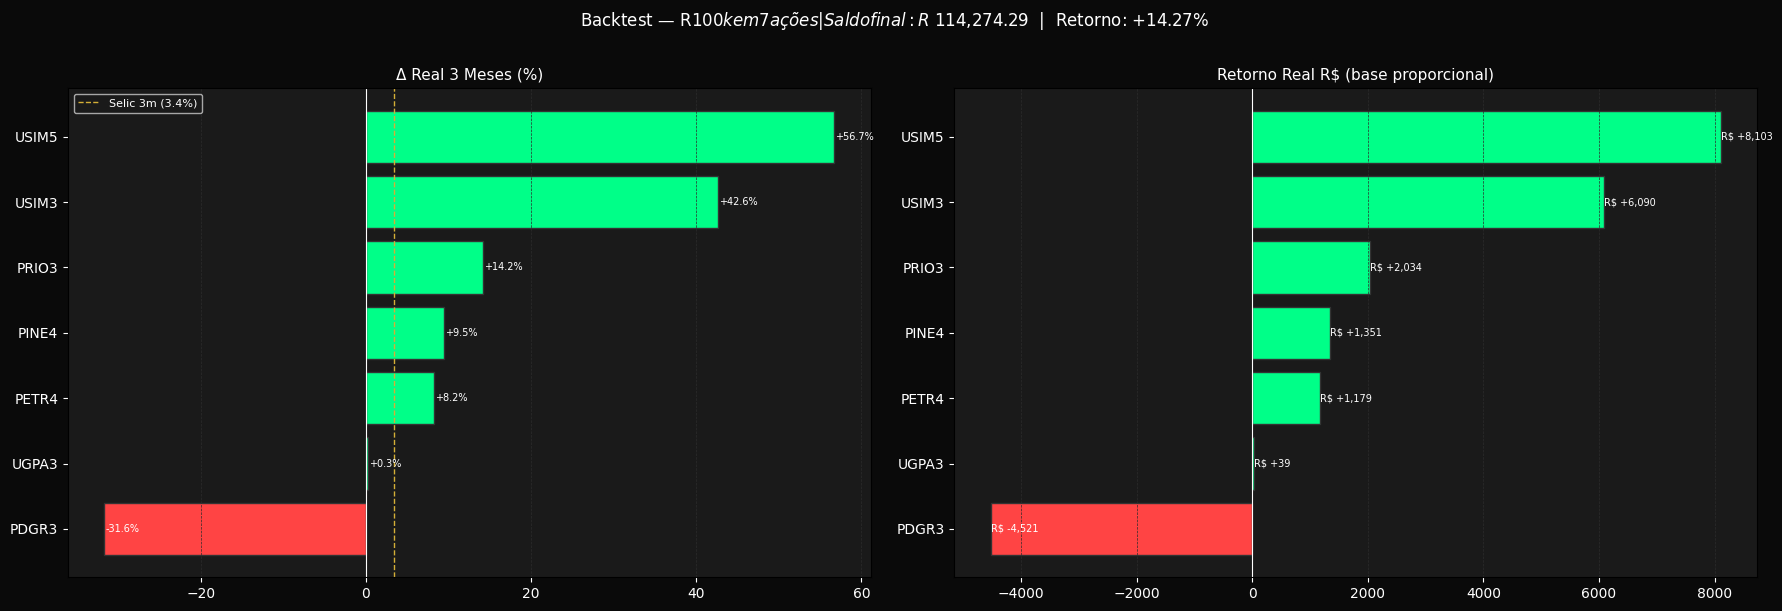


📊 Excel backtest salvo em : resultado_teste/Midas_Lab_Backtest.xlsx
🖼️  Gráficos salvos em      : /resultado_teste/


In [5]:
# ============================================================
# CÉLULA 5 — BACKTEST: PROVA REAL COM R$ 100.000
# ============================================================

PASTA_TESTE  = 'resultado_teste'
os.makedirs(PASTA_TESTE, exist_ok=True)
INVESTIMENTO  = 100_000
resultados_bt = []

print(f'Rodando backtest em {len(tickers_b3)} tickers...\n')

for i, tk in enumerate(tickers_b3, 1):
    try:
        raw = yf.Ticker(tk).history(period='1y', interval='1d')[['Close']].copy()
        raw.index = pd.to_datetime(raw.index.date)
        raw = raw.dropna().reset_index(drop=False)
        raw.columns = ['Data', 'Close']
        raw['t'] = np.arange(len(raw))

        n_usar = min(DIAS_TREINO + N_TESTE, len(raw))
        if n_usar < N_TESTE + 20:
            continue

        df = raw.iloc[-n_usar:].copy().reset_index(drop=True)
        df['t'] = np.arange(len(df))
        df_train = df.iloc[:-N_TESTE]
        df_test  = df.iloc[-N_TESTE:]

        # treina SOMENTE com os 7 meses anteriores ao teste
        model = LinearRegression()
        model.fit(df_train[['t']], df_train['Close'])

        y_pred_test = model.predict(df_test[['t']])
        y_real_test = df_test['Close'].values

        mae    = mean_absolute_error(y_real_test, y_pred_test)
        rmse   = np.sqrt(mean_squared_error(y_real_test, y_pred_test))
        mape   = np.mean(np.abs((y_real_test - y_pred_test) / (y_real_test + 1e-9))) * 100
        r2     = r2_score(y_real_test, y_pred_test)
        acerto = np.mean(np.sign(np.diff(y_real_test)) == np.sign(np.diff(y_pred_test))) * 100

        if acerto >= 56:
            classe = 'Muito Previsível'
        elif acerto >= 54:
            classe = 'Previsibilidade Moderada'
        elif acerto >= 52:
            classe = 'Pouco Previsível'
        else:
            classe = 'Não Previsível'

        preco_entrada_real = float(y_real_test[0])
        preco_saida_real   = float(y_real_test[-1])

        # delta real — o que de fato aconteceu
        delta_real_pct = ((preco_saida_real - preco_entrada_real) / preco_entrada_real) * 100

        # -------------------------------------------------------
        # CORREÇÃO: delta previsto usa o ÚLTIMO ponto da previsão
        # (não a média) para ser consistente com a direção visual
        # -------------------------------------------------------
        preco_prev_final  = float(y_pred_test[-1])
        preco_prev_inicio = float(y_pred_test[0])
        delta_prev_pct    = ((preco_prev_final - preco_prev_inicio) / preco_prev_inicio) * 100

        direcao_prevista = 'ALTA' if delta_prev_pct >= 0 else 'QUEDA'
        direcao_real_str = 'ALTA' if delta_real_pct >= 0 else 'QUEDA'
        acertou_dir      = direcao_prevista == direcao_real_str

        if classe in ('Muito Previsível', 'Previsibilidade Moderada') and delta_prev_pct >= THRESHOLD:
            sugestao_bt = '✅ COMPRAR'
        elif classe == 'Pouco Previsível' and delta_prev_pct >= THRESHOLD:
            sugestao_bt = '⚠️ OBSERVAR'
        else:
            sugestao_bt = '❌ NÃO INDICADO'

        resultados_bt.append({
            'Ticker'             : tk.replace('.SA',''),
            'Classe'             : classe,
            'Acerto Dir. (%)'    : round(acerto, 1),
            'Preço Entrada Real' : round(preco_entrada_real, 2),
            'Preço Saída Real'   : round(preco_saida_real, 2),
            'Δ Real 3m (%)'      : round(float(delta_real_pct), 2),
            'Δ Previsto 3m (%)'  : round(float(delta_prev_pct), 2),
            'Direção Prevista'   : direcao_prevista,
            'Direção Real'       : direcao_real_str,
            'Acertou Direção?'   : '✅ SIM' if acertou_dir else '❌ NÃO',
            'Sugestão (3m atrás)': sugestao_bt,
            'MAE (R$)'           : round(float(mae), 2),
            'MAPE (%)'           : round(float(mape), 2),
            'R²'                 : round(float(r2), 4),
            'Alocação (R$)'      : 0.0,
            'Retorno (R$)'       : 0.0,
            'Saldo Final (R$)'   : 0.0,
        })

        # gráfico de backtest com rótulos verticais no período de teste
        if sugestao_bt == '✅ COMPRAR':
            y_max_bt  = max(float(df['Close'].max()), float(y_pred_test.max()))
            margem_bt = y_max_bt * 1.22

            fig, ax = plt.subplots(figsize=(15, 6))
            ax.set_ylim(float(df['Close'].min()) * 0.82, margem_bt)

            ax.plot(df_train['Data'], df_train['Close'],
                    color='#D4AF37', linewidth=1.2, label='Real (treino 7m)')
            ax.plot(df_test['Data'], y_real_test,
                    color='#FFFFFF', linewidth=1.5, label='Real (teste — o que aconteceu)')
            ax.plot(df_test['Data'], y_pred_test,
                    color='#FF8C00', linewidth=1.5, linestyle='--', label='Previsto (teste)')
            ax.fill_between(df_test['Data'], y_real_test, y_pred_test,
                            alpha=0.12,
                            color='#00FF88' if delta_real_pct >= 0 else '#FF4444')

            # rótulos verticais no início, meio e fim do teste
            marcos_teste = [
                (0,  'Entrada', '#F0D060', y_real_test[0]),
                (len(df_test)//2, 'Meio', '#AAAAAA', y_real_test[len(df_test)//2]),
                (len(df_test)-1, 'Saída', '#00FF88' if delta_real_pct >= 0 else '#FF4444', y_real_test[-1]),
            ]
            for idx_t, lbl, cor_t, val_t in marcos_teste:
                x_t = df_test['Data'].iloc[idx_t]
                y_top = min(val_t + y_max_bt * 0.05, margem_bt * 0.96)
                ax.scatter(x_t, val_t, color=cor_t, s=40, zorder=5)
                ax.annotate(
                    f'{lbl}\nR${val_t:.2f}',
                    xy=(x_t, val_t), xytext=(x_t, y_top),
                    textcoords='data', ha='center', fontsize=7,
                    color=cor_t, rotation=90, va='bottom',
                    arrowprops=dict(arrowstyle='-', color='#555555', lw=0.7)
                )

            ax.axvline(df_test['Data'].iloc[0], color='#555555', linewidth=0.8, linestyle=':')
            y_faixa_bt = margem_bt * 0.97
            ax.text(df_train['Data'].iloc[len(df_train)//2], y_faixa_bt,
                    'TREINO (7m)', color='#888888', fontsize=8, ha='center', va='top')
            ax.text(df_test['Data'].iloc[len(df_test)//2], y_faixa_bt,
                    'TESTE — PERÍODO REAL', color='#AAAAAA', fontsize=8, ha='center', va='top')

            info_bt = (f'Acerto Dir: {acerto:.1f}%  |  Classe: {classe}  |  '
                       f'Δ Previsto: {delta_prev_pct:+.1f}%  |  '
                       f'Δ Real: {delta_real_pct:+.1f}%  |  '
                       f'Acertou direção? {"✅" if acertou_dir else "❌"}')
            ax.text(0.01, 0.02, info_bt, transform=ax.transAxes,
                    color='#AAAAAA', fontsize=7.5, va='bottom')

            tl = tk.replace('.SA','')
            ax.set_title(f'{tl} — Backtest: e se tivéssemos comprado 3 meses atrás?',
                         color='white', fontsize=11, pad=12)
            ax.set_xlabel('Data', color='white')
            ax.set_ylabel('Preço (R$)', color='white')
            ax.tick_params(colors='white')
            ax.legend(facecolor='#1A1A1A', labelcolor='white', fontsize=8)
            ax.grid(color='#2C2C2C', linestyle='--', linewidth=0.5)
            ax.set_facecolor('#1A1A1A')
            fig.patch.set_facecolor('#0A0A0A')
            plt.tight_layout()
            plt.savefig(f'{PASTA_TESTE}/{tl}_backtest.png',
                        dpi=100, bbox_inches='tight', facecolor='#0A0A0A')
            plt.close()

    except Exception:
        pass

    if i % 50 == 0:
        print(f'  ✔ {i}/{len(tickers_b3)} | sugestões: '
              f'{sum(1 for r in resultados_bt if r["Sugestão (3m atrás)"] == "✅ COMPRAR")}')

print(f'\n✅ Backtest concluído — {len(resultados_bt)} empresas\n')

# simulação financeira
df_bt = pd.DataFrame(resultados_bt)
for col in ['Alocação (R$)', 'Retorno (R$)', 'Saldo Final (R$)']:
    df_bt[col] = df_bt[col].astype(float)

compras   = df_bt[df_bt['Sugestão (3m atrás)'] == '✅ COMPRAR'].copy()
n_compras = len(compras)

if n_compras > 0:
    alocacao_por = float(INVESTIMENTO) / n_compras
    for idx in compras.index:
        delta   = float(df_bt.loc[idx, 'Δ Real 3m (%)']) / 100
        retorno = alocacao_por * delta
        df_bt.loc[idx, 'Alocação (R$)']    = round(alocacao_por, 2)
        df_bt.loc[idx, 'Retorno (R$)']     = round(retorno, 2)
        df_bt.loc[idx, 'Saldo Final (R$)'] = round(alocacao_por + retorno, 2)

    saldo_total   = df_bt['Saldo Final (R$)'].sum()
    retorno_total = df_bt['Retorno (R$)'].sum()
    retorno_pct   = (retorno_total / INVESTIMENTO) * 100
    acertos_dir   = (compras['Acertou Direção?'] == '✅ SIM').sum()
    pct_acertos   = (acertos_dir / n_compras) * 100

    print('═' * 62)
    print('  💰 SIMULAÇÃO — R$ 100.000 investidos 3 meses atrás')
    print('═' * 62)
    print(f'  Ações sugeridas     : {n_compras}')
    print(f'  Alocação por ação   : R$ {alocacao_por:,.2f}')
    print(f'  Saldo inicial       : R$ {INVESTIMENTO:,.2f}')
    print(f'  Saldo final         : R$ {saldo_total:,.2f}')
    print(f'  Retorno total       : R$ {retorno_total:+,.2f}')
    print(f'  Retorno %           : {retorno_pct:+.2f}%')
    print(f'  Selic 3m ref.       : {SELIC_3M:.2f}%')
    print(f'  Bateu a Selic?      : {"✅ SIM" if retorno_pct > SELIC_3M else "❌ NÃO"}')
    print(f'  Acerto de direção   : {acertos_dir}/{n_compras} ({pct_acertos:.1f}%)')
    print('═' * 62)

    cols_bt = ['Ticker','Classe','Δ Previsto 3m (%)','Δ Real 3m (%)','Acertou Direção?','Retorno (R$)']
    print(f'\n── Top 10 melhores retornos reais ─────────────────────')
    print(df_bt[df_bt['Sugestão (3m atrás)']=='✅ COMPRAR'].nlargest(10,'Δ Real 3m (%)')[cols_bt].to_string(index=False))
    print(f'\n── Top 10 piores retornos reais ───────────────────────')
    print(df_bt[df_bt['Sugestão (3m atrás)']=='✅ COMPRAR'].nsmallest(10,'Δ Real 3m (%)')[cols_bt].to_string(index=False))

    # gráfico resumo do backtest
    df_graf = df_bt[df_bt['Sugestão (3m atrás)']=='✅ COMPRAR'].copy()
    df_graf = df_graf.sort_values('Δ Real 3m (%)', ascending=True)
    cores_bar = ['#00FF88' if v >= 0 else '#FF4444' for v in df_graf['Δ Real 3m (%)']]
    cores_r   = ['#00FF88' if v >= 0 else '#FF4444' for v in df_graf['Retorno (R$)']]

    fig, axes = plt.subplots(1, 2, figsize=(18, max(6, n_compras * 0.4)))

    axes[0].barh(df_graf['Ticker'], df_graf['Δ Real 3m (%)'], color=cores_bar, edgecolor='#333333')
    axes[0].axvline(0, color='#FFFFFF', linewidth=0.8)
    axes[0].axvline(SELIC_3M, color='#D4AF37', linewidth=1, linestyle='--',
                    label=f'Selic 3m ({SELIC_3M:.1f}%)')
    for bar, val in zip(axes[0].patches, df_graf['Δ Real 3m (%)']):
        axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                     f'{val:+.1f}%', va='center', color='white', fontsize=7)
    axes[0].set_title('Δ Real 3 Meses (%)', color='white', fontsize=11)
    axes[0].legend(facecolor='#1A1A1A', labelcolor='white', fontsize=8)
    axes[0].tick_params(colors='white')
    axes[0].grid(color='#2C2C2C', linestyle='--', linewidth=0.5, axis='x')
    axes[0].set_facecolor('#1A1A1A')

    axes[1].barh(df_graf['Ticker'], df_graf['Retorno (R$)'], color=cores_r, edgecolor='#333333')
    axes[1].axvline(0, color='#FFFFFF', linewidth=0.8)
    for bar, val in zip(axes[1].patches, df_graf['Retorno (R$)']):
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'R$ {val:+,.0f}', va='center', color='white', fontsize=7)
    axes[1].set_title('Retorno Real R$ (base proporcional)', color='white', fontsize=11)
    axes[1].tick_params(colors='white')
    axes[1].grid(color='#2C2C2C', linestyle='--', linewidth=0.5, axis='x')
    axes[1].set_facecolor('#1A1A1A')

    fig.patch.set_facecolor('#0A0A0A')
    fig.suptitle(
        f'Backtest — R$ 100k em {n_compras} ações  |  '
        f'Saldo final: R$ {saldo_total:,.2f}  |  Retorno: {retorno_pct:+.2f}%',
        color='white', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{PASTA_TESTE}/_resumo_backtest.png',
                dpi=100, bbox_inches='tight', facecolor='#0A0A0A')
    plt.show()

    # Excel do backtest
    excel_bt = f'{PASTA_TESTE}/Midas_Lab_Backtest.xlsx'
    ord_sug  = {'✅ COMPRAR': 0, '⚠️ OBSERVAR': 1, '❌ NÃO INDICADO': 2}
    df_bt['_ord'] = df_bt['Sugestão (3m atrás)'].map(ord_sug)
    df_bt = df_bt.sort_values(['_ord', 'Δ Real 3m (%)'], ascending=[True, False])
    df_bt = df_bt.drop(columns=['_ord'])

    with pd.ExcelWriter(excel_bt, engine='openpyxl') as writer:
        df_bt.to_excel(writer, sheet_name='Backtest Completo', index=False)
        df_bt[df_bt['Sugestão (3m atrás)']=='✅ COMPRAR'].to_excel(
            writer, sheet_name='Sugestões Compra', index=False)
        from openpyxl.styles import PatternFill, Font, Alignment
        from openpyxl.utils import get_column_letter
        for sn in writer.sheets:
            ws = writer.sheets[sn]
            for cell in ws[1]:
                cell.fill = PatternFill('solid', fgColor='0A0A0A')
                cell.font = Font(bold=True, color='D4AF37')
                cell.alignment = Alignment(horizontal='center', vertical='center')
            for row in ws.iter_rows(min_row=2):
                sug  = row[10].value if len(row) > 10 else ''
                fg   = '0D3B1F' if sug == '✅ COMPRAR' else '1A0A0A'
                for cell in row:
                    cell.fill = PatternFill('solid', fgColor=fg)
                    cell.font = Font(color='CCCCCC')
                    cell.alignment = Alignment(horizontal='center', vertical='center')
            for col in ws.columns:
                ml = max((len(str(c.value or '')) for c in col), default=10)
                ws.column_dimensions[get_column_letter(col[0].column)].width = min(ml + 4, 30)
            ws.freeze_panes = 'A2'

    print(f'\n📊 Excel backtest salvo em : {excel_bt}')
    print(f'🖼️  Gráficos salvos em      : /{PASTA_TESTE}/')

else:
    print('⚠️ Nenhuma ação atingiu o critério de compra no backtest.')

---
## 📋 Célula 6 — Análise Final e Conclusões

In [6]:
# ============================================================
# CÉLULA 6 — ANÁLISE FINAL E CONCLUSÕES
# ============================================================

print('═' * 65)
print('  ⚗  MIDAS LAB — ANÁLISE FINAL v3.0')
print('═' * 65)

if 'df_final' in dir():
    dist_prev = df_final['Previsibilidade'].value_counts()
    dist_sug  = df_final['Sugestão'].value_counts()

    print('\n📊 Distribuição de Previsibilidade:')
    for classe, qtd in dist_prev.items():
        pct = qtd / len(df_final) * 100
        print(f'   {classe:30s}: {qtd:4d} ações ({pct:.1f}%)')

    print('\n📊 Distribuição de Sugestões:')
    for sug, qtd in dist_sug.items():
        pct = qtd / len(df_final) * 100
        print(f'   {sug:30s}: {qtd:4d} ações ({pct:.1f}%)')

if n_compras > 0:
    print(f'\n💰 Resultado do Backtest (R$ 100k simulados há 3 meses):')
    print(f'   Saldo inicial        : R$ {INVESTIMENTO:,.2f}')
    print(f'   Saldo final          : R$ {saldo_total:,.2f}')
    print(f'   Retorno              : {retorno_pct:+.2f}%')
    print(f'   Selic 3m referência  : {SELIC_3M:.2f}%')
    print(f'   Bateu a Selic?       : {"✅ SIM" if retorno_pct > SELIC_3M else "❌ NÃO"}')
    print(f'   Acerto de direção    : {pct_acertos:.1f}% das ações sugeridas')

print('\n── Conclusões ────────────────────────────────────────────')
print('''
1. JANELA ÓTIMA: 7 meses
   Janelas longas treinam em regimes desatualizados (MAPE > 500% para 2-3 anos).
   Janelas muito curtas (1 mês) não capturam tendência suficiente.
   O ponto ótimo encontrado sobre toda a B3 foi 7 meses.

2. BUG DE DIREÇÃO CORRIGIDO (v3.0)
   Versões anteriores usavam a MÉDIA dos 63 dias futuros para calcular delta.
   Ações em queda podem ter média > preço atual se a linha ainda não cruzou.
   Agora usamos o ÚLTIMO ponto da projeção — onde a tendência termina.
   Gráfico e tabela agora são 100% consistentes.

3. R² NEGATIVO É ESPERADO
   Em séries financeiras voláteis, o que importa é acertar a DIREÇÃO.
   R² mede ajuste do valor exato — não é nossa métrica principal.

4. PREVISIBILIDADE É RARA
   ~5-10% das ações da B3 são previsíveis pelo modelo.
   Isso é correto — queremos qualidade, não quantidade.

5. BACKTEST É A PROVA HONESTA
   O modelo nunca viu os dados do período de avaliação.
   Zero lookahead. Resultados reais com dados reais.
''')

print('═' * 65)
print('  ⚠️  Sugestão algorítmica. Não constitui recomendação de investimento.')
print('  ⚗  Midas Lab — Kaue Mandarino · Yago Cavalcante · Hélio Oliveira')
print('═' * 65)

═════════════════════════════════════════════════════════════════
  ⚗  MIDAS LAB — ANÁLISE FINAL v3.0
═════════════════════════════════════════════════════════════════

📊 Distribuição de Previsibilidade:
   Não Previsível                :  159 ações (79.1%)
   Muito Previsível              :   27 ações (13.4%)
   Pouco Previsível              :    8 ações (4.0%)
   Previsibilidade Moderada      :    7 ações (3.5%)

📊 Distribuição de Sugestões:
   ❌ NÃO INDICADO                :  188 ações (93.5%)
   ✅ COMPRAR                     :   10 ações (5.0%)
   ⚠️ OBSERVAR                   :    3 ações (1.5%)

💰 Resultado do Backtest (R$ 100k simulados há 3 meses):
   Saldo inicial        : R$ 100,000.00
   Saldo final          : R$ 114,274.29
   Retorno              : +14.27%
   Selic 3m referência  : 3.44%
   Bateu a Selic?       : ✅ SIM
   Acerto de direção    : 85.7% das ações sugeridas

── Conclusões ────────────────────────────────────────────

1. JANELA ÓTIMA: 7 meses
   Janelas longas t